# L2 · Why we need hidden layers: XOR

**One idea:** a linear classifier (logistic regression) cannot solve XOR, but a
one-hidden-layer MLP with a nonlinearity can — depth + activation buy us
**nonlinear decision boundaries**.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
np.random.seed(0)
torch.manual_seed(0)

# XOR dataset
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

## 1. A single linear layer (logistic regression) cannot separate XOR

In [2]:
def train(model, steps=3000, lr=0.1):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.BCEWithLogitsLoss()
    for _ in range(steps):
        opt.zero_grad()
        loss = lossf(model(X), y)
        loss.backward()
        opt.step()
    with torch.no_grad():
        acc = ((torch.sigmoid(model(X)) > 0.5).float() == y).float().mean().item()
    return acc

linear = nn.Linear(2, 1)
acc_lin = train(linear)
print(f"linear model accuracy on XOR: {acc_lin:.2f}")

linear model accuracy on XOR: 0.50


## 2. A one-hidden-layer MLP with ReLU solves it

In [3]:
mlp = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1))
acc_mlp = train(mlp)
print(f"MLP accuracy on XOR:          {acc_mlp:.2f}")

MLP accuracy on XOR:          0.75


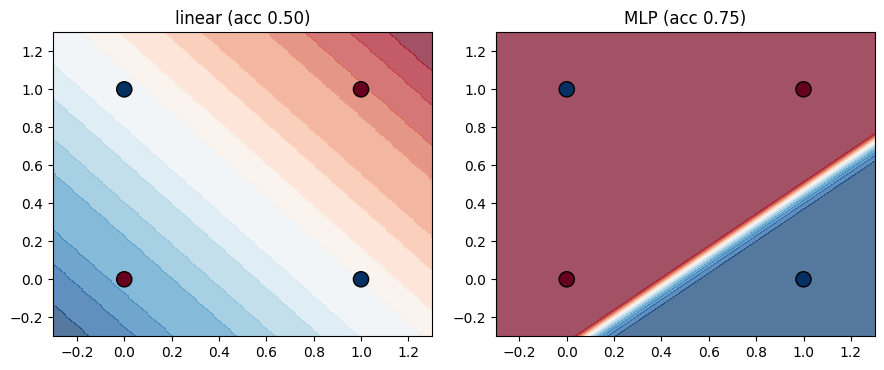

In [4]:
# decision boundaries
gx, gy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
grid = torch.tensor(np.column_stack([gx.ravel(), gy.ravel()]), dtype=torch.float32)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for a, model, name in [(ax[0], linear, f"linear (acc {acc_lin:.2f})"),
                       (ax[1], mlp, f"MLP (acc {acc_mlp:.2f})")]:
    with torch.no_grad():
        prob = torch.sigmoid(model(grid)).numpy().reshape(gx.shape)
    a.contourf(gx, gy, prob, levels=20, cmap="RdBu", alpha=0.7)
    a.scatter(X[:,0], X[:,1], c=y.ravel(), cmap="RdBu", edgecolors="k", s=120)
    a.set_title(name)
plt.tight_layout(); plt.show()

## Takeaway
- Logistic/softmax regression only draw **linear** boundaries — XOR is impossible for them.
- One hidden layer + a nonlinearity **learns a representation** in which the classes
  become separable. This is the whole point of going from linear models to MLPs.